# Active Lives 2018-19 — London EDA & Multi-Pillar Analysis (Wave 4)

Same template as the other wave notebooks, **configured to what the diagnostics proved about this
wave**. 2018-19 is the richest wave onboarded so far: all four pillars **plus `health`**.

**Verified for 2018-19:**

| Item | 2018-19 |
|---|---|
| Rows | 15,889 × 545 |
| Geography | `LA_2021`, **wave-specific map from this wave’s own `.sav`** |
| Borough codes | **4 swapped vs the shared map** (8⇉9 Barnet/Barking, 138⇉139 K&C/Islington) — same as 2017-18 |
| Vintage agreement | `LA_2015` / `LA_2020` / `LA_2021` / `LA_2023` resolve to the **same GSS for all 15,889 respondents** |
| Ethnicity | `Eth7[3]` = **"South Asian"** |
| Activity | code 2 = Active (middle band "Insufficiently Active" — cosmetic) |
| NS-SEC | 5 codes (incl. "Aged <16 or 75+") |
| Health | **PRESENT** → included in the regression (unlike 2015-16 / 2016-17 / 2017-18) |
| Volunteering | present, **0/1 coded**, 62.9% non-null → Pillar 4 runs (subgroup) |
| Indoor/Outdoor | present, **34.5% rotation subgroup** → Pillar 3 runs, indicative only |

> Coverage on `LA_2021` was 1.000 with all 33 codes present — yet 4 codes mean *different boroughs*
> than the shared map claims. Coverage never proves correctness; the GSS does. Coherence with the
> other waves is guaranteed by joining the panel on **`gss`**, not the integer.


## 1. Load the pre-filtered London CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV      = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y4_2018-19.csv"
SAV_2018 = r"C:\Users\Lenovo\London-Sport-Forecasting-Patterns\data\raw\active_lives_survey_nov_18-19_data_year_4_shared_20250103.sav"

df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique() if "survey_year" in df else "?")

shape: (15889, 545) | year: ['2018-19']


## 2. Codebook — decode numeric codes to labels

Verified against this wave's `.sav` via `compare_codebooks`. Wave-specific: **`Eth7[3]` = "South
Asian"**, activity middle band "Insufficiently Active" (cosmetic — we target code 2 = Active),
**NSSEC5 has a 5th code**, and **`VolAny` is 0/1** here, decoded explicitly so the `"Volunteered"`
target matches every other wave.

In [2]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01":     {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "Gend3":  {1: "Male", 2: "Female", 3: "Other"},
    "Eth7":   {1: "White British", 2: "White Other", 3: "South Asian",      # <-- wave-specific
               4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9":   {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
               6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)",  4: "Students and other/unclassified",
               5: "Aged <16 or 75+"},                                        # <-- 5th code
    "Educ6":  {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
               4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "BMIG":   {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese"},
    "VolAny": {0: "Not volunteered", 1: "Volunteered"},                      # <-- 0/1 in this wave
}

VOL_ROLES = {f"volint{i}_vol": f"role {i}" for i in range(1, 8)}
print("codebook entries:", len(CODEBOOK))

codebook entries: 11


## 3. Borough map — derived from **this wave's own `.sav`**, then proven

The shared `LONDON_LA2021` is **not** used: 4 of this wave's codes mean different boroughs.
We derive the map from `LA_2021`'s own GSS-bearing labels, verify it, print the swaps for the
record, and confirm all four vintage columns agree on GSS.

In [3]:
import pyreadstat

def build_london_map_from_sav(sav_path, la_col):
    """Derive {int_code: (gss, name)} from a wave's OWN .sav value labels."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    m = {}
    for cd, lbl in labels.items():
        s = str(lbl)
        if s.startswith("E09"):
            gss = s.split()[0]
            m[int(cd)] = (gss, s[len(gss):].strip())
    return m

def verify_borough_mapping(sav_path, la_col, london_map):
    """Prove each integer -> GSS from the wave's own labels."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    mism = [f"code {c}: map says {g} {n}  |  .sav says {labels.get(c)!r}"
            for c, (g, n) in london_map.items()
            if labels.get(c) is not None and g not in str(labels.get(c))]
    print("=== verify ->", "PROVEN OK" if not mism else f"{len(mism)} MISMATCH", "===")
    for x in mism:
        print("  -", x)
    return not mism

LA_COL = "LA_2021"
LONDON_MAP = build_london_map_from_sav(SAV_2018, LA_COL)
print(f"{LA_COL}: {len(LONDON_MAP)} London codes derived from this wave's .sav")
verify_borough_mapping(SAV_2018, LA_COL, LONDON_MAP)

# Divergence from the shared map (what a coverage check would MISS)
from active_lives_utils import LONDON_LA2021 as SHARED
swaps = [f"code {c}: shared={SHARED[c][0]} {SHARED[c][1]}  |  2018-19={g} {n}"
         for c, (g, n) in LONDON_MAP.items() if c in SHARED and SHARED[c][0] != g]
print("\n=== vs shared map ->", "SAME NUMBERING" if not swaps else f"{len(swaps)} SWAPPED CODE(S)", "===")
for s in swaps:
    print("  -", s)

# All vintage columns must resolve to the SAME GSS per respondent
vint = ["LA_2015", "LA_2020", "LA_2021", "LA_2023"]
maps = {la: build_london_map_from_sav(SAV_2018, la) for la in vint}
gsscheck = pd.DataFrame({la: df[la].map({k: v[0] for k, v in m.items()}) for la, m in maps.items()})
print("\nall vintages agree on GSS for every respondent:", gsscheck.nunique(axis=1).eq(1).all())

LA_2021: 33 London codes derived from this wave's .sav
=== verify -> PROVEN OK ===

=== vs shared map -> 4 SWAPPED CODE(S) ===
  - code 8: shared=E09000003 Barnet  |  2018-19=E09000002 Barking and Dagenham
  - code 9: shared=E09000002 Barking and Dagenham  |  2018-19=E09000003 Barnet
  - code 138: shared=E09000020 Kensington and Chelsea  |  2018-19=E09000019 Islington
  - code 139: shared=E09000019 Islington  |  2018-19=E09000020 Kensington and Chelsea

all vintages agree on GSS for every respondent: True


## 4. Configure, decode, and build the London analysis frame

In [4]:
CONFIG = {
    "weight": "wt_final", "la_code": LA_COL,
    "activity_band": "MEMS7GR_SPORTCOUNT_A01",
    "activity_in":   "MEMS7GR_IN_SPORTCOUNT_A01",
    "activity_out":  "MEMS7GR_OUT_SPORTCOUNT_A01",
    "age": "Age9", "gender": "Gend3", "ethnicity": "Eth7", "disability": "Disab3",
    "nssec": "NSSEC5", "education": "Educ6", "bmi": "BMIG",
    "health": "health",          # <-- PRESENT in this wave
    "volunteer": "VolAny",
}

def decode(df, config, codebook):
    out = df.copy()
    for concept, var in config.items():
        if var in codebook:
            out[concept] = out[var].map(codebook[var])
        elif var in out.columns:
            out[concept] = out[var]
    out["weight"] = pd.to_numeric(out[config["weight"]], errors="coerce")
    return out

# Exclude 14-15 (out of scope for the adult survey)
df = df[df["Age9"] != 1.0].copy()
data = decode(df, CONFIG, CODEBOOK)

# Apply THIS WAVE'S map, restrict to the 32 boroughs (exclude City of London)
data["gss"]     = data[LA_COL].map({k: v[0] for k, v in LONDON_MAP.items()})
data["LA_name"] = data[LA_COL].map({k: v[1] for k, v in LONDON_MAP.items()})
london = data[data["gss"].notna() & (data["gss"] != "E09000001")].copy()

print("borough coverage (this wave's map):", data["gss"].notna().mean())
assert london["LA_name"].nunique() == 32, f"Expected 32 boroughs, got {london['LA_name'].nunique()}"
print(f"London analysis frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs")

# Sanity anchor on the two boroughs the swap would have transposed
print("\nBarnet n =", (london["LA_name"] == "Barnet").sum(),
      "| Barking and Dagenham n =", (london["LA_name"] == "Barking and Dagenham").sum())

borough coverage (this wave's map): 1.0
London analysis frame: 15,889 rows, 32 boroughs

Barnet n = 471 | Barking and Dagenham n = 494


## 5. Weighted summary helpers

In [5]:
def weighted_share(df, group_cols, target_col, target_value):
    """NOTE: the returned `n` is the count of respondents who ANSWERED target_col
    (post-dropna), i.e. the base size -- not the number in the target category."""
    d = df.dropna(subset=["weight", target_col]).copy()
    d["_num"] = (d[target_col] == target_value).astype(float) * d["weight"]
    if group_cols:
        g = d.groupby(group_cols, dropna=False)
        out = (g["_num"].sum() / g["weight"].sum()).rename("weighted_share").reset_index()
        out["n"] = g.size().values
        return out
    return d["_num"].sum() / d["weight"].sum()

def weighted_distribution(df, group_col, target_col="activity_band"):
    d = df.dropna(subset=["weight", target_col, group_col]).copy()
    tab = d.groupby([group_col, target_col])["weight"].sum().unstack(fill_value=0)
    return tab.div(tab.sum(axis=1), axis=0)

## 6. EDA — missingness map

Ordinary item non-response (a few %) vs **structural** missingness on rotation modules
(indoor/outdoor ~65%, volunteering ~37%). Structural missingness is by design — it means those
pillars run on a smaller, indicative base, not that the data is faulty.

activity_in      0.655
activity_out     0.655
volunteer        0.371
bmi              0.181
nssec            0.076
disability       0.069
ethnicity        0.069
education        0.037
health           0.025
age              0.011
gender           0.002
activity_band    0.000
weight           0.000


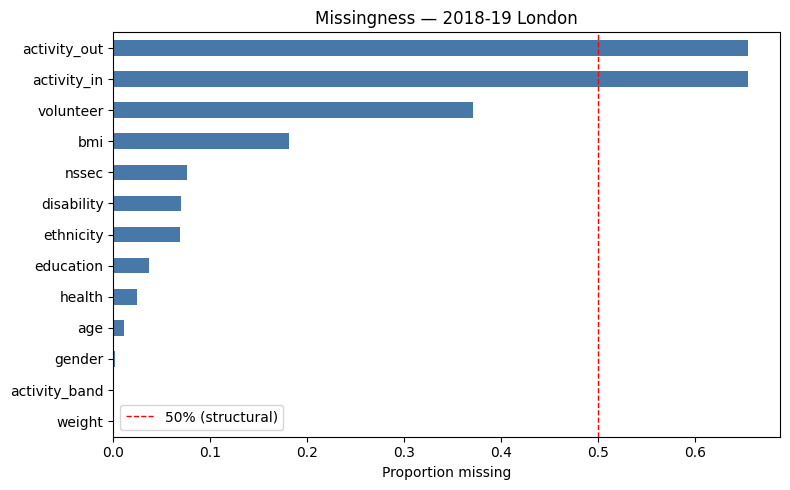

In [6]:
concept_cols = ["activity_band","activity_in","activity_out","age","gender","ethnicity",
                "disability","nssec","education","health","bmi","volunteer","weight"]
miss = london[concept_cols].isna().mean().sort_values(ascending=False)
print(miss.round(3).to_string())

fig, ax = plt.subplots(figsize=(8,5))
miss.sort_values().plot(kind="barh", ax=ax, color="#4878a8")
ax.axvline(0.5, color="red", ls="--", lw=1, label="50% (structural)")
ax.set_xlabel("Proportion missing"); ax.set_title("Missingness — 2018-19 London")
ax.legend(); plt.tight_layout(); plt.show()

In [7]:
def check_routing(df, gate_col, gate_value, dependent_cols, label=""):
    """Among rows where gate_col==gate_value, how complete are the dependents?
    ~0% missing = clean universal routing; high+uniform = rotation subsample."""
    cols = [c for c in dependent_cols if c in df.columns]
    if not cols:
        print(f"{label or gate_col}: no dependent columns present"); return
    sub = df[df[gate_col] == gate_value]
    m = sub[cols].isna().mean().round(3)
    all_blank = sub[cols].isna().all(axis=1).sum()
    print(f"{label or gate_col}=={gate_value!r} (n={len(sub)}): "
          f"max dep-missing={m.max():.3f}, all-blank={all_blank} ({all_blank/max(len(sub),1):.1%})")

role_cols = [c for c in london.columns if c.startswith("volint")]
check_routing(london, "volunteer", "Volunteered", role_cols, "Volunteer -> role detail")
disty = [c for c in london.columns if c.startswith("disty")]
check_routing(london, "disability", "Limiting disability", disty, "Limiting disability -> impairment types")

Volunteer -> role detail=='Volunteered' (n=1563): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment types=='Limiting disability' (n=2160): max dep-missing=0.017, all-blank=36 (1.7%)


## 7. EDA — weight validity & sample composition

Weight: min=0.1755 max=16.82 non-positive=0 missing=0


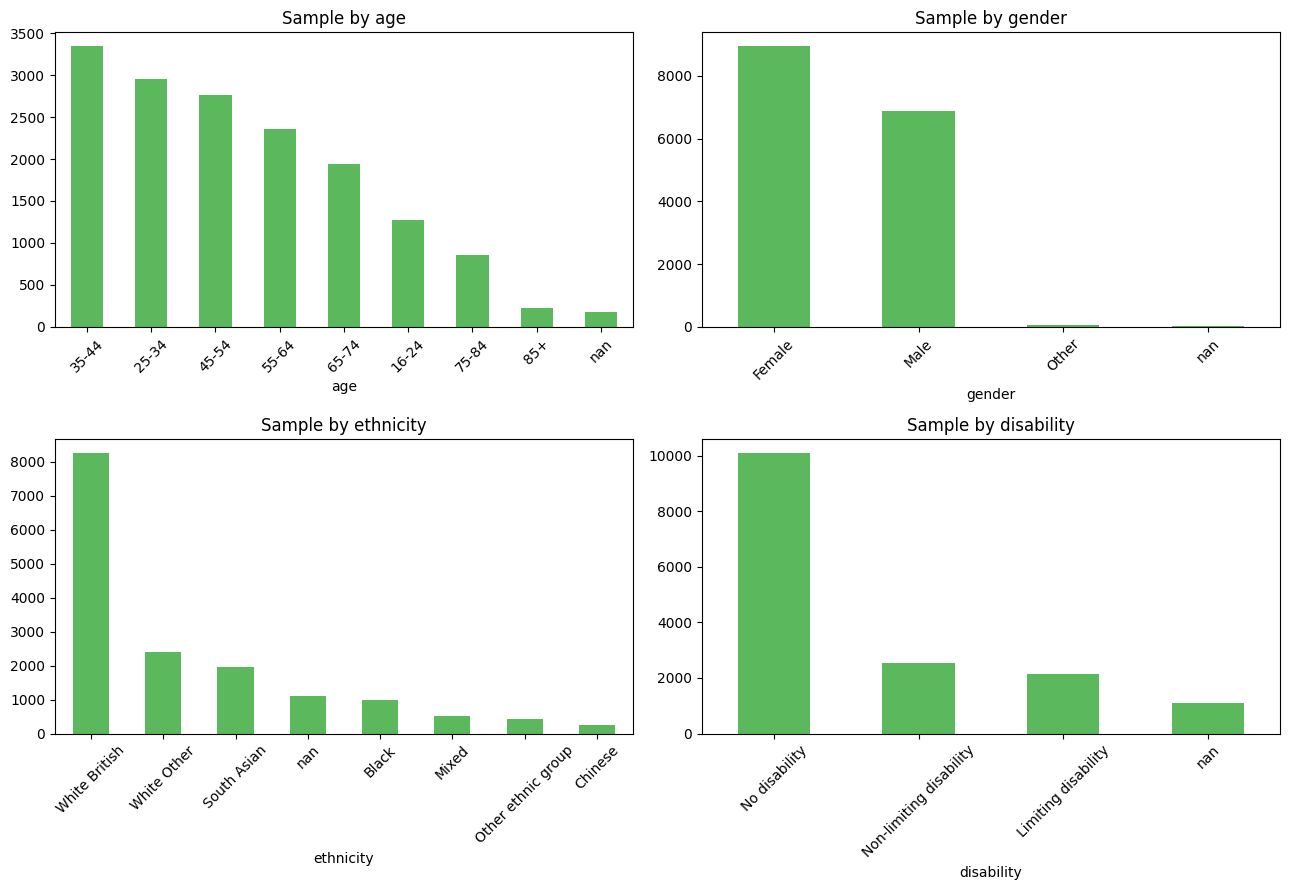

In [8]:
w = london["weight"]
print("Weight: min={:.4f} max={:.2f} non-positive={} missing={}".format(
    w.min(), w.max(), int((w<=0).sum()), int(w.isna().sum())))

fig, axes = plt.subplots(2,2, figsize=(13,9))
for ax, c in zip(axes.ravel(), ["age","gender","ethnicity","disability"]):
    london[c].value_counts(dropna=False).plot(kind="bar", ax=ax, color="#5cb85c")
    ax.set_title(f"Sample by {c}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 8. Pillar 1 — Participation / activity levels
Overall, by demographic, and by borough. Benchmarks: 2015-16 London 63.5%, 2017-18 London 64.6%.

In [9]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2018-19): {overall:.3f}   (2015-16: 0.635 | 2017-18: 0.646)")
for factor in ["age","gender","ethnicity","disability","nssec","education","health","bmi"]:
    print(f"\n=== % Active by {factor} ===")
    print(weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor]).to_string(index=False))

Overall London % Active (2018-19): 0.645   (2015-16: 0.635 | 2017-18: 0.646)

=== % Active by age ===
  age  weighted_share    n
16-24        0.721920 1272
25-34        0.693832 2959
35-44        0.657733 3342
45-54        0.650517 2760
55-64        0.606765 2355
65-74        0.593921 1942
75-84        0.469075  861
  85+        0.223952  222

=== % Active by gender ===
gender  weighted_share    n
Female        0.620781 8939
  Male        0.671074 6867
 Other        0.446932   50

=== % Active by ethnicity ===
         ethnicity  weighted_share    n
             Black        0.600103  983
           Chinese        0.657184  259
             Mixed        0.673427  509
Other ethnic group        0.617413  430
       South Asian        0.538002 1956
     White British        0.700112 8259
       White Other        0.681722 2397

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.495267  2160
          No disability        0.677537 

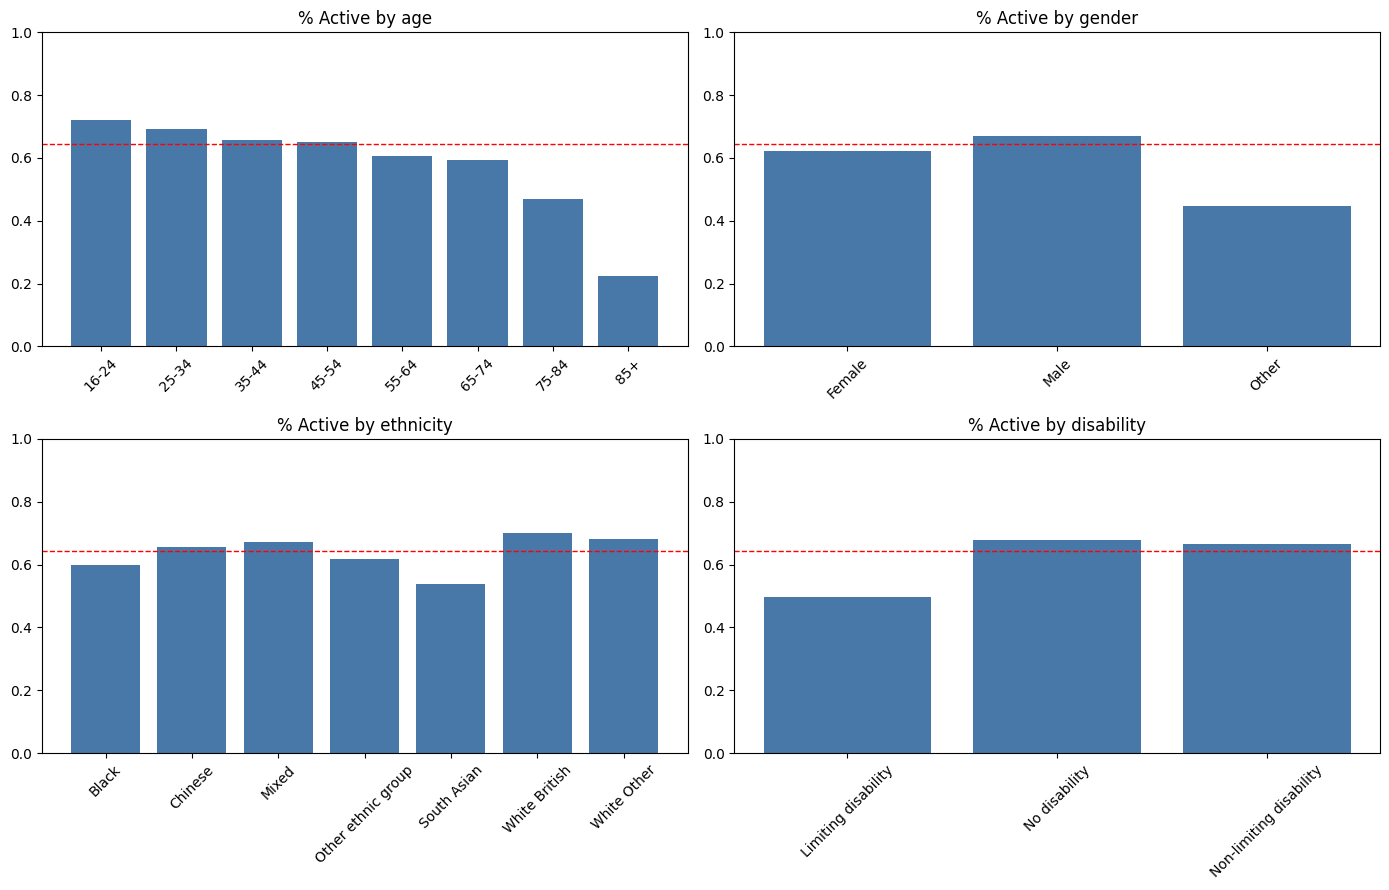

In [10]:
factors = ["age","gender","ethnicity","disability"]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax, factor in zip(axes.ravel(), factors):
    res = weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor])
    ax.bar(res[factor].astype(str), res["weighted_share"], color="#4878a8")
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_ylim(0,1)
    ax.set_title(f"% Active by {factor}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share   n
  Barking and Dagenham        0.474752 494
                Newham        0.550509 481
                 Brent        0.563033 502
            Hillingdon        0.565148 506
                Barnet        0.570656 471
             Redbridge        0.582472 486
                Ealing        0.583292 490
               Croydon        0.587511 487
                Bexley        0.592192 489
              Havering        0.599879 507
             Greenwich        0.607685 486
                Harrow        0.612504 482
              Hounslow        0.628318 523
               Enfield        0.654793 492
               Bromley        0.660758 487
        Waltham Forest        0.660987 472
                Merton        0.663762 511
               Hackney        0.667467 497
         Tower Hamlets        0.673498 510
                Camden        0.674516 491
              Haringey        0.677137 495
                Sutton        0.681037 534
Kensington 

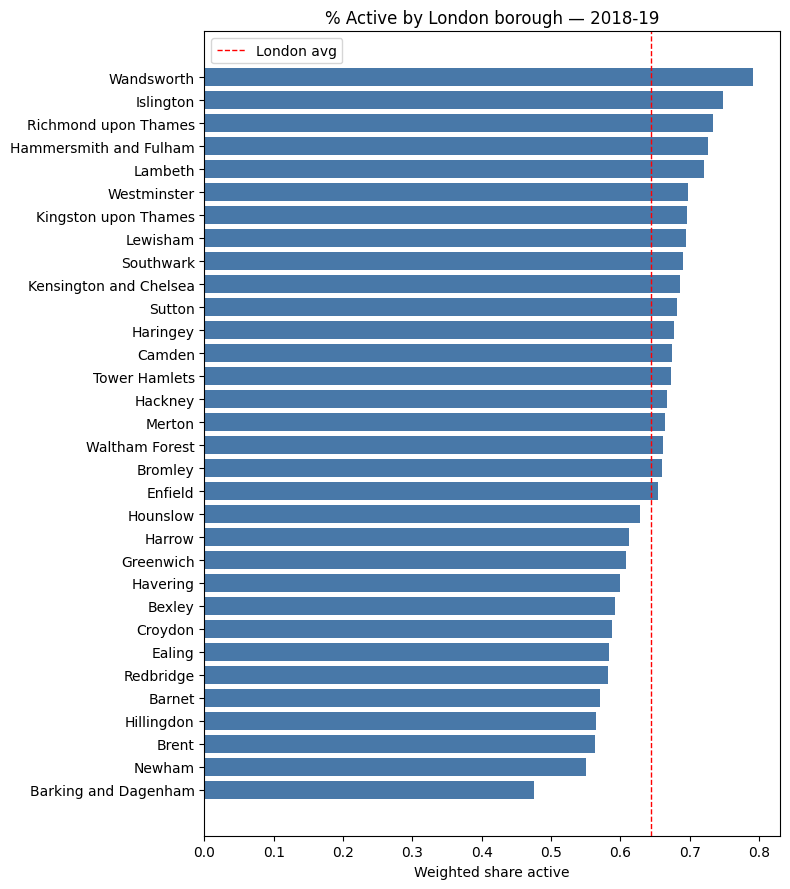

In [11]:
bor = weighted_share(london, ["LA_name"], "activity_band", "Active").sort_values("weighted_share")
print(bor.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_xlabel("Weighted share active"); ax.set_title("% Active by London borough — 2018-19")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Pillar 2 — Demographics: relationships between variables
Cramér's V (0 = independent, 1 = perfectly associated). `health` is present this wave, so it is
included — matching the 2022-23 model.

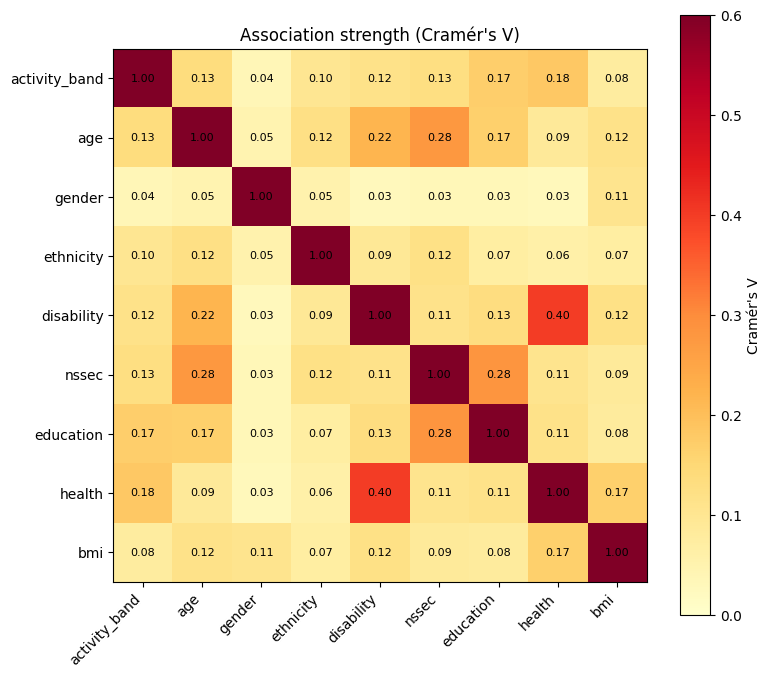

In [12]:
from itertools import combinations
from scipy.stats import chi2_contingency
assoc = ["activity_band","age","gender","ethnicity","disability","nssec","education","health","bmi"]

def cramers_v(a, b, df):
    t = pd.crosstab(df[a], df[b])
    if t.shape[0] < 2 or t.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(t)[0]; n = t.values.sum(); r, k = t.shape
    return np.sqrt((chi2/n) / (min(r-1, k-1)))

M = pd.DataFrame(np.eye(len(assoc)), index=assoc, columns=assoc)
for a, b in combinations(assoc, 2):
    v = cramers_v(a, b, london); M.loc[a,b] = M.loc[b,a] = v

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(M.values, cmap="YlOrRd", vmin=0, vmax=0.6)
ax.set_xticks(range(len(assoc))); ax.set_xticklabels(assoc, rotation=45, ha="right")
ax.set_yticks(range(len(assoc))); ax.set_yticklabels(assoc)
for i in range(len(assoc)):
    for j in range(len(assoc)):
        ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Association strength (Cramér's V)")
fig.colorbar(im, label="Cramér's V"); plt.tight_layout(); plt.show()

## 10. Pillar 3 — Indoor vs Outdoor
Rotation-subgroup questions — only **34.5%** of respondents were asked. Indicative, not headline.

Indoor/outdoor base: 5,481 of 15,889 (34.5%)
Indoor: weighted % active = 0.286
Outdoor: weighted % active = 0.571

% Active indoor vs outdoor by ethnicity:
place               Indoor  Outdoor
ethnicity                          
Black                0.298    0.470
Chinese              0.292    0.588
Mixed                0.306    0.623
Other ethnic group   0.296    0.543
South Asian          0.228    0.464
White British        0.302    0.633
White Other          0.318    0.632


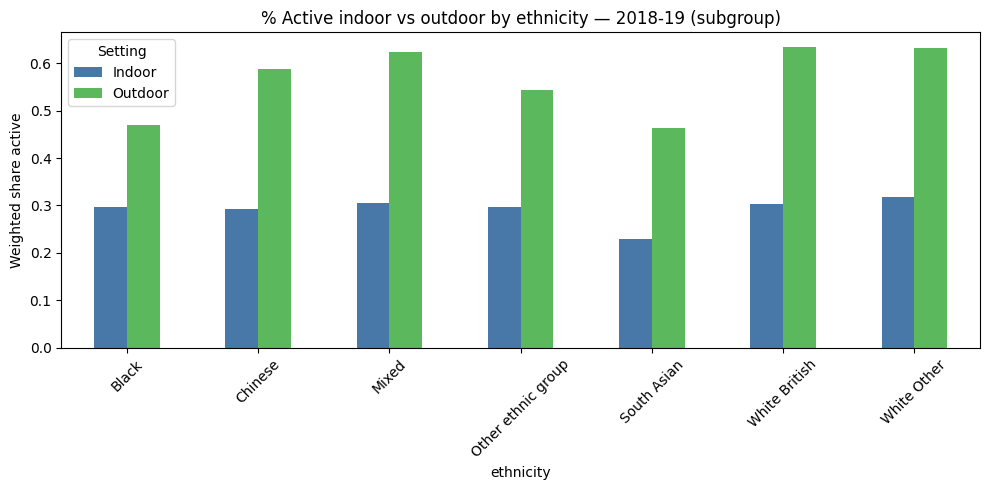

In [13]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,} ({len(io)/len(london):.1%})")
for place, col in [("Indoor","activity_in"), ("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io, [], col, 'Active'):.3f}")

rows = []
for col, place in [("activity_in","Indoor"), ("activity_out","Outdoor")]:
    r = weighted_share(io, ["ethnicity"], col, "Active").dropna(subset=["ethnicity"]); r["place"] = place; rows.append(r)
pivot = pd.concat(rows).pivot(index="ethnicity", columns="place", values="weighted_share")
print("\n% Active indoor vs outdoor by ethnicity:"); print(pivot.round(3).to_string())
pivot.plot(kind="bar", figsize=(10,5), color=["#4878a8","#5cb85c"])
plt.title("% Active indoor vs outdoor by ethnicity — 2018-19 (subgroup)")
plt.ylabel("Weighted share active"); plt.xticks(rotation=45); plt.legend(title="Setting")
plt.tight_layout(); plt.show()

### Pillar 3 — indoor vs outdoor by borough (subgroup — small n, indicative)

In [14]:
rows = []
for col, place in [("activity_in","Indoor"), ("activity_out","Outdoor")]:
    r = weighted_share(io, ["LA_name"], col, "Active").dropna(subset=["LA_name"]); r["place"] = place; rows.append(r)
bor_io = pd.concat(rows).pivot(index="LA_name", columns="place", values="weighted_share")
print(bor_io.round(3).to_string())

place                   Indoor  Outdoor
LA_name                                
Barking and Dagenham     0.216    0.395
Barnet                   0.225    0.512
Bexley                   0.255    0.561
Brent                    0.250    0.487
Bromley                  0.299    0.612
Camden                   0.298    0.581
Croydon                  0.199    0.472
Ealing                   0.261    0.508
Enfield                  0.255    0.571
Greenwich                0.268    0.527
Hackney                  0.277    0.568
Hammersmith and Fulham   0.364    0.543
Haringey                 0.264    0.603
Harrow                   0.316    0.527
Havering                 0.359    0.479
Hillingdon               0.185    0.480
Hounslow                 0.248    0.565
Islington                0.372    0.668
Kensington and Chelsea   0.312    0.618
Kingston upon Thames     0.293    0.655
Lambeth                  0.383    0.650
Lewisham                 0.340    0.569
Merton                   0.254    0.467


## 11. Pillar 4 — Volunteering
`VolAny` is **0/1** in this wave (decoded above to the `"Volunteered"` target). 62.9% non-null —
a rotation subgroup, so treat as indicative.

In [15]:
volr = weighted_share(london, [], "volunteer", "Volunteered")
print(f"Overall weighted % volunteered: {volr:.3f}")
print("volunteer value counts:", london["volunteer"].value_counts(dropna=False).to_dict())
for factor in ["age","gender","disability","nssec"]:
    print(f"\n=== % Volunteered by {factor} ===")
    print(weighted_share(london, [factor], "volunteer", "Volunteered").dropna(subset=[factor]).to_string(index=False))

Overall weighted % volunteered: 0.160
volunteer value counts: {'Not volunteered': 8435, nan: 5891, 'Volunteered': 1563}

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.256895  710
25-34        0.137427 1767
35-44        0.150240 2033
45-54        0.184839 1762
55-64        0.134961 1537
65-74        0.140352 1296
75-84        0.105959  607
  85+        0.132080  172

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.139874 5663
  Male        0.179571 4289
 Other        0.290796   25

=== % Volunteered by disability ===
             disability  weighted_share    n
    Limiting disability        0.117556 1443
          No disability        0.165327 6172
Non-limiting disability        0.168721 1731

=== % Volunteered by nssec ===
                            nssec  weighted_share    n
Higher social groups (NS-SEC 1-2)        0.167868 5631
 Lower social groups (NS-SEC 6-8)        0.107366  902
Middle social groups (NS-SEC 3-5)        0.15672

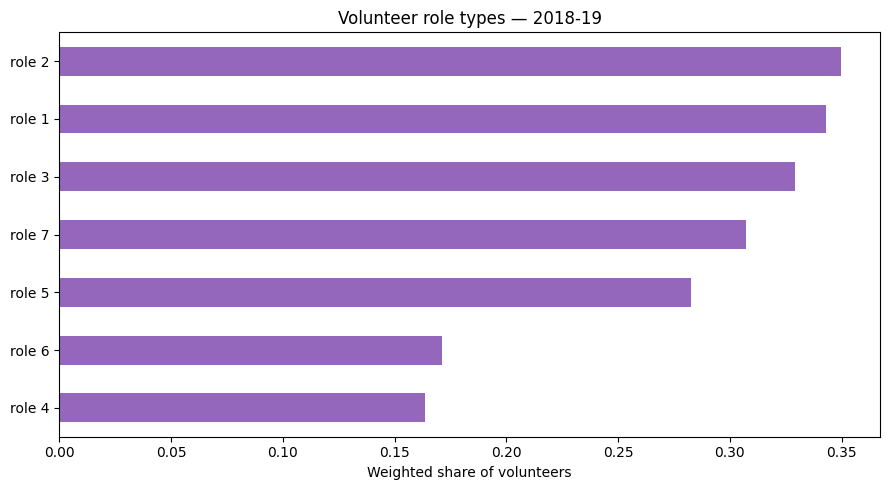

role 4    0.164
role 6    0.171
role 5    0.283
role 7    0.307
role 3    0.329
role 1    0.343
role 2    0.350


In [16]:
vols = london[london["volunteer"] == "Volunteered"].dropna(subset=["weight"]).copy()
role_share = {}
for col, label in VOL_ROLES.items():
    if col in vols.columns:
        d = vols.dropna(subset=[col])
        if len(d):
            role_share[label] = (d[col] * d["weight"]).sum() / d["weight"].sum()

if role_share:
    rs = pd.Series(role_share).sort_values()
    fig, ax = plt.subplots(figsize=(9,5))
    rs.plot(kind="barh", ax=ax, color="#9467bd")
    ax.set_xlabel("Weighted share of volunteers"); ax.set_title("Volunteer role types — 2018-19")
    plt.tight_layout(); plt.show()
    print(rs.round(3).to_string())
else:
    print("No volint*_vol role columns present — headline VolAny only.")

### Pillar 4 — volunteering rate by borough

In [17]:
vbor = weighted_share(london, ["LA_name"], "volunteer", "Volunteered").sort_values("weighted_share")
print(vbor.to_string(index=False))

               LA_name  weighted_share   n
                Newham        0.110426 292
              Lewisham        0.110762 320
                Camden        0.111697 299
             Redbridge        0.115014 313
             Greenwich        0.120849 303
  Barking and Dagenham        0.126403 304
         Tower Hamlets        0.129614 311
Kensington and Chelsea        0.132099 300
            Wandsworth        0.133550 332
                Harrow        0.136234 296
Hammersmith and Fulham        0.136621 329
               Hackney        0.137206 320
        Waltham Forest        0.139213 281
                Barnet        0.139551 289
                Ealing        0.150454 313
                Merton        0.151432 318
              Haringey        0.153983 297
               Enfield        0.157396 311
                Bexley        0.163676 324
               Lambeth        0.164874 308
             Islington        0.168925 302
  Kingston upon Thames        0.169573 321
           

## 12. Weighted regression — drivers of being active (adjusted)
`health` **is** included this wave (present, unlike 2015-16 / 2016-17 / 2017-18), so this model
matches the 2022-23 specification.

**Caveats:** `freq_weights` treats survey weights as frequencies — p-values and CIs are unreliable,
so read the odds ratios as directional. Also note `NSSEC5` code 5 is "Aged <16 or 75+", which is
collinear with the oldest age bands and will absorb them; a `nssec`-free variant is run alongside
so the age gradient can be read cleanly.

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

m = london.dropna(subset=["activity_band","age","gender","disability",
                          "ethnicity","nssec","health","weight"]).copy()
m["active"] = (m["activity_band"] == "Active").astype(int)
print(f"Regression complete-case sample: {len(m):,} of {len(london):,} "
      f"({len(m)/len(london):.0%}) — {len(london)-len(m):,} rows dropped for missing predictors. "
      f"Complete-case deletion may bias estimates if missingness is non-random.")

model = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British")) '
    '+ C(nssec) + C(health)',
    data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(model.summary())

Regression complete-case sample: 12,855 of 15,889 (81%) — 3,034 rows dropped for missing predictors. Complete-case deletion may bias estimates if missingness is non-random.
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:                12855
Model:                            GLM   Df Residuals:                 23001.23
Model Family:                Binomial   Df Model:                           22
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13462.
Date:                Sat, 18 Jul 2026   Deviance:                       26924.
Time:                        13:41:06   Pearson chi2:                 2.29e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1509
Covariance Type:            nonrobust                                         
                                     

In [19]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params), "p_value": model.pvalues,
    "ci_low": np.exp(model.conf_int()[0]), "ci_high": np.exp(model.conf_int()[1]),
}).round(3)
print(or_table.to_string())

# Variant WITHOUT nssec, so the oldest age bands are not absorbed by NSSEC5 code 5
m2 = london.dropna(subset=["activity_band","age","gender","disability","ethnicity","health","weight"]).copy()
m2["active"] = (m2["activity_band"] == "Active").astype(int)
model2 = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British")) '
    '+ C(health)',
    data=m2, family=sm.families.Binomial(), freq_weights=m2["weight"]).fit()
print("\n=== age gradient without nssec (n={:,}) ===".format(len(m2)))
print(np.exp(model2.params).filter(like="age").round(3).to_string())

                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            7.817    0.000   6.839    8.934
C(age)[T.25-34]                                                                      0.727    0.000   0.647    0.816
C(age)[T.35-44]                                                                      0.681    0.000   0.604    0.768
C(age)[T.45-54]                                                                      0.664    0.000   0.586    0.752
C(age)[T.55-64]                                                                      0.548    0.000   0.481    0.625
C(age)[T.65-74]                                                                      0.399    0.000   0.346    0.460
C(gender, Treatment(reference="Female"))[T.Male]                                     1.183    0.000   1.115    1.254
C(gender, Treatment(reference="Female"))[T.Other]               

## 13. Save cleaned data & wave comparison

In [20]:
london.to_parquet("london_2018_19_clean.parquet")
print("saved london_2018_19_clean.parquet", london.shape)
print("gss present:", "gss" in london.columns, "| non-null:", london["gss"].notna().sum())

import os
PARQUETS = {
    "2015-16": "london_2015_16_clean.parquet",
    "2016-17": "london_2016_17_clean.parquet",
    "2017-18": "london_2017_18_clean.parquet",
    "2018-19": "london_2018_19_clean.parquet",
    "2019-20": "london_2019_20_clean.parquet",
    "2021-22": "london_2021_22_clean.parquet",
    "2022-23": "london_2022_23_clean.parquet",
}
rows = []
for wv, p in PARQUETS.items():
    if os.path.exists(p):
        d = pd.read_parquet(p)
        rows.append({"wave": wv, "overall_pct_active": round(weighted_share(d, [], "activity_band", "Active"), 4)})
print(pd.DataFrame(rows).to_string(index=False))

saved london_2018_19_clean.parquet (15889, 560)
gss present: True | non-null: 15889
   wave  overall_pct_active
2015-16              0.6347
2016-17              0.6228
2017-18              0.6461
2018-19              0.6446
2019-20              0.6227
2021-22              0.6427
2022-23              0.6434


## Findings — to complete after running

- **Verification:** borough map PROVEN OK from this wave's `.sav`; **4 codes swapped vs shared map**
  (same as 2017-18); all four LA vintages agree on GSS for every respondent.
- **Overall active rate 2018-19:** ___ % (2015-16: 63.5% | 2017-18: 64.6%).
  *Sanity band:* England was ~62-63% these years and London runs ~1-2pp above, so expect ~63-66%.
- **Borough range:** highest ___ , lowest ___ . *Expect Islington/Camden near the top and
  Barking & Dagenham near the bottom* — if Barnet and Barking look transposed, the map is wrong.
- **Indoor vs outdoor:** ___ (34.5% subgroup base — indicative only).
- **Volunteering:** ___ % overall (62.9% base).
- **Regression:** strongest adjusted drivers ___ ; health odds ratio ___ .


In [21]:
# Is disability's sign restored when health is removed?
m3 = london.dropna(subset=["activity_band","age","gender","disability","ethnicity","nssec","weight"]).copy()
m3["active"] = (m3["activity_band"]=="Active").astype(int)
mod3 = smf.glm('active ~ C(age) + C(gender, Treatment(reference="Female")) '
               '+ C(disability, Treatment(reference="No disability")) '
               '+ C(ethnicity, Treatment(reference="White British")) + C(nssec)',
               data=m3, family=sm.families.Binomial(), freq_weights=m3["weight"]).fit()
print(np.exp(mod3.params).filter(like="disability").round(3))
# Cramér's V between them:
print("V(disability, health) =", cramers_v("disability","health",london).round(3))

C(disability, Treatment(reference="No disability"))[T.Limiting disability]        0.638
C(disability, Treatment(reference="No disability"))[T.Non-limiting disability]    1.023
dtype: float64
V(disability, health) = 0.399


In [22]:
d22 = pd.read_parquet("london_2022_23_clean.parquet")
print("V(disability, health) 2022-23 =", cramers_v("disability","health",d22).round(3))

V(disability, health) 2022-23 = 0.414
